<a href="https://colab.research.google.com/github/alexandrumoldovan1/housing-prices-ml/blob/main/notebooks/03_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install libraries
!pip install category_encoders -q

# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Category encoders for target encoding
from category_encoders import TargetEncoder

# Visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Define paths
DRIVE_PATH = '/content/drive/MyDrive/ColabProjects/housing-prices-ml'
PROCESSED_DATA_PATH = f'{DRIVE_PATH}/processed_data'
OUTPUTS_PATH = f'{DRIVE_PATH}/outputs'

# Load raw data from Notebook 01
df = pd.read_parquet(f'{PROCESSED_DATA_PATH}/raw_data.parquet')

print(f"Data loaded successfully!")
print(f"   Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data loaded successfully!
   Shape: 239,722 rows x 23 columns


In [3]:
# Drop columns with too many missing values or low utility
columns_to_drop = ['EASE-MENT', 'APARTMENT NUMBER']
df = df.drop(columns=columns_to_drop)
print(f"Dropped columns: {columns_to_drop}")

# Filter out non-commercial transactions (price < $10,000)
initial_rows = len(df)
df = df[df['SALE PRICE'] > 10000].copy()
removed = initial_rows - len(df)
print(f"\nRemoved {removed:,} non-commercial transactions ({removed/initial_rows*100:.2f}%)")

# Filter out extreme price outliers (top 0.1% and bottom 0.1%)
lower = df['SALE PRICE'].quantile(0.001)
upper = df['SALE PRICE'].quantile(0.999)
before_outliers = len(df)
df = df[(df['SALE PRICE'] >= lower) & (df['SALE PRICE'] <= upper)].copy()
print(f"Removed {before_outliers - len(df):,} extreme price outliers (below ${lower:,.0f} or above ${upper:,.0f})")

print(f"\nCurrent shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

Dropped columns: ['EASE-MENT', 'APARTMENT NUMBER']

Removed 86,076 non-commercial transactions (35.91%)
Removed 244 extreme price outliers (below $17,173 or above $170,256,052)

Current shape: 153,402 rows x 21 columns


In [4]:
# Inspect YEAR BUILT distribution
print("YEAR BUILT statistics before cleaning:\n")
print(df['YEAR BUILT'].describe().round(2).to_string())

# Mark invalid years as NaN (years before 1800 or after current year are errors)
df.loc[(df['YEAR BUILT'] < 1800) | (df['YEAR BUILT'] > 2025), 'YEAR BUILT'] = np.nan

# Impute missing YEAR BUILT with median (per borough for better accuracy)
df['YEAR BUILT'] = df.groupby('borough_name')['YEAR BUILT'].transform(
    lambda x: x.fillna(x.median())
)

print(f"\nYEAR BUILT statistics after cleaning:\n")
print(df['YEAR BUILT'].describe().round(2).to_string())
print(f"\nMissing values remaining: {df['YEAR BUILT'].isnull().sum()}")

YEAR BUILT statistics before cleaning:

count    143360.00
mean       1954.76
std          36.93
min         190.00
25%        1925.00
50%        1950.00
75%        1982.00
max        2025.00

YEAR BUILT statistics after cleaning:

count    153402.00
mean       1954.33
std          35.58
min        1800.00
25%        1927.00
50%        1950.00
75%        1975.00
max        2025.00

Missing values remaining: 0


In [5]:
from sklearn.impute import KNNImputer

# Inspect square feet columns
print("SQUARE FEET statistics before cleaning:\n")
print(df[['LAND  SQUARE FEET', 'GROSS  SQUARE FEET']].describe().round(2).to_string())

# Mark zero values as NaN (zero sqft is invalid)
df.loc[df['LAND  SQUARE FEET'] == 0, 'LAND  SQUARE FEET'] = np.nan
df.loc[df['GROSS  SQUARE FEET'] == 0, 'GROSS  SQUARE FEET'] = np.nan

print(f"\nMissing values before KNN imputation:")
print(f"   LAND SQUARE FEET: {df['LAND  SQUARE FEET'].isnull().sum():,}")
print(f"   GROSS SQUARE FEET: {df['GROSS  SQUARE FEET'].isnull().sum():,}")

# Prepare features for KNN imputation
# Use numerical features that are mostly complete to predict missing sqft
print("\nRunning KNN imputation (this may take 5-15 minutes)...")

knn_features = ['LAND  SQUARE FEET', 'GROSS  SQUARE FEET', 'YEAR BUILT',
                'BLOCK', 'LOT', 'ZIP CODE', 'RESIDENTIAL UNITS',
                'COMMERCIAL UNITS', 'TOTAL  UNITS', 'sale_year']

# Encode borough temporarily for KNN to use it
df['borough_code'] = df['borough_name'].astype('category').cat.codes
knn_features.append('borough_code')

# Apply KNN imputation
imputer = KNNImputer(n_neighbors=5, weights='distance')
df[knn_features] = imputer.fit_transform(df[knn_features])

# Drop temporary borough code
df = df.drop(columns=['borough_code'])

print(f"\nSQUARE FEET statistics after KNN imputation:\n")
print(df[['LAND  SQUARE FEET', 'GROSS  SQUARE FEET']].describe().round(2).to_string())
print(f"\nMissing values remaining:")
print(f"   LAND SQUARE FEET: {df['LAND  SQUARE FEET'].isnull().sum()}")
print(f"   GROSS SQUARE FEET: {df['GROSS  SQUARE FEET'].isnull().sum()}")

SQUARE FEET statistics before cleaning:

       LAND  SQUARE FEET  GROSS  SQUARE FEET
count           70042.00            70042.00
mean             7363.08             7279.37
std            137212.09            47943.50
min                 0.00                0.00
25%              2000.00             1336.00
50%              2500.00             1904.00
75%              4000.00             2794.00
max           9166500.00          2161994.00

Missing values before KNN imputation:
   LAND SQUARE FEET: 83,388
   GROSS SQUARE FEET: 86,510

Running KNN imputation (this may take 5-15 minutes)...

SQUARE FEET statistics after KNN imputation:

       LAND  SQUARE FEET  GROSS  SQUARE FEET
count          153402.00           153402.00
mean             8957.71            18884.51
std             93894.19            55749.99
min                16.00                1.00
25%              2400.00             1810.00
50%              3900.00             3290.13
75%              6692.87            1699

In [6]:
# Handle remaining numerical columns with missing values
remaining_cols = ['ZIP CODE', 'RESIDENTIAL UNITS', 'COMMERCIAL UNITS', 'TOTAL  UNITS']

print("Missing values in remaining numerical columns:")
print(df[remaining_cols].isnull().sum().to_string())

# Impute with median per borough
for col in remaining_cols:
    df[col] = df.groupby('borough_name')[col].transform(
        lambda x: x.fillna(x.median())
    )
    # Fallback to global median
    df[col] = df[col].fillna(df[col].median())

print(f"\nAfter imputation:")
print(df[remaining_cols].isnull().sum().to_string())

Missing values in remaining numerical columns:
ZIP CODE             0
RESIDENTIAL UNITS    0
COMMERCIAL UNITS     0
TOTAL  UNITS         0

After imputation:
ZIP CODE             0
RESIDENTIAL UNITS    0
COMMERCIAL UNITS     0
TOTAL  UNITS         0


In [7]:
# Convert SALE DATE to datetime
df['SALE DATE'] = pd.to_datetime(df['SALE DATE'], errors='coerce')

# Create new features
print("Creating new features...\n")

# Time-based features
df['sale_month'] = df['SALE DATE'].dt.month
df['sale_quarter'] = df['SALE DATE'].dt.quarter
df['sale_dayofweek'] = df['SALE DATE'].dt.dayofweek

# Building age at time of sale
df['building_age'] = df['sale_year'] - df['YEAR BUILT']
df.loc[df['building_age'] < 0, 'building_age'] = 0  # Fix any inverted dates

# Price per square foot (only for valid GROSS SQUARE FEET)
df['price_per_sqft'] = df['SALE PRICE'] / df['GROSS  SQUARE FEET']
df.loc[df['price_per_sqft'] == np.inf, 'price_per_sqft'] = np.nan
df['price_per_sqft'] = df['price_per_sqft'].fillna(df['price_per_sqft'].median())

# Borough average price (target encoding for borough)
df['borough_avg_price'] = df.groupby('borough_name')['SALE PRICE'].transform('median')

# Neighborhood average price
df['neighborhood_avg_price'] = df.groupby('NEIGHBORHOOD')['SALE PRICE'].transform('median')

# Is recent construction (built in last 20 years)
df['is_recent_construction'] = (df['building_age'] <= 20).astype(int)

# Has commercial units
df['has_commercial'] = (df['COMMERCIAL UNITS'] > 0).astype(int)

print("New features created:")
new_features = ['sale_month', 'sale_quarter', 'sale_dayofweek', 'building_age',
                'price_per_sqft', 'borough_avg_price', 'neighborhood_avg_price',
                'is_recent_construction', 'has_commercial']
print(df[new_features].describe().round(2).to_string())

Creating new features...

New features created:
       sale_month  sale_quarter  sale_dayofweek  building_age  price_per_sqft  borough_avg_price  neighborhood_avg_price  is_recent_construction  has_commercial
count   153402.00     153402.00       153402.00     153402.00       153402.00          153402.00               153402.00               153402.00       153402.00
mean         6.62          2.53            2.08         69.70          918.94          929003.87              1003064.05                    0.17            0.51
std          3.37          1.10            1.38         35.59       187684.93          245712.58               568115.79                    0.37            0.50
min          1.00          1.00            0.00          0.00            0.04          650000.00               230000.00                    0.00            0.00
25%          4.00          2.00            1.00         49.00           62.81          710000.00               695000.00                    0.00   

In [8]:
# Cap extreme values in price_per_sqft (winsorization at 99th percentile)
print("Price per sqft - before capping:")
print(df['price_per_sqft'].describe().round(2).to_string())

upper_cap = df['price_per_sqft'].quantile(0.99)
lower_cap = df['price_per_sqft'].quantile(0.01)
df['price_per_sqft'] = df['price_per_sqft'].clip(lower=lower_cap, upper=upper_cap)

print(f"\nCapped at 1st percentile (${lower_cap:,.2f}) and 99th percentile (${upper_cap:,.2f})")
print("\nPrice per sqft - after capping:")
print(df['price_per_sqft'].describe().round(2).to_string())

Price per sqft - before capping:
count      153402.00
mean          918.94
std        187684.93
min             0.04
25%            62.81
50%           243.80
75%           507.95
max      73500000.00

Capped at 1st percentile ($2.05) and 99th percentile ($3,513.83)

Price per sqft - after capping:
count    153402.00
mean        366.23
std         482.29
min           2.05
25%          62.81
50%         243.80
75%         507.95
max        3513.83


In [9]:
# Identify categorical columns to encode
categorical_cols = ['NEIGHBORHOOD', 'BUILDING CLASS CATEGORY', 'TAX CLASS AT PRESENT',
                    'BUILDING CLASS AT PRESENT', 'BUILDING CLASS AT TIME OF SALE',
                    'borough_name']

print("Categorical columns and unique values:\n")
for col in categorical_cols:
    print(f"   {col}: {df[col].nunique()} unique values")

# One-hot encode borough_name (only 5 categories - safe)
df = pd.get_dummies(df, columns=['borough_name'], prefix='borough', drop_first=False)

# Target encode high-cardinality categoricals (NEIGHBORHOOD has many values)
high_card_cols = ['NEIGHBORHOOD', 'BUILDING CLASS CATEGORY', 'TAX CLASS AT PRESENT',
                  'BUILDING CLASS AT PRESENT', 'BUILDING CLASS AT TIME OF SALE']

# Apply target encoding using SALE PRICE
encoder = TargetEncoder(cols=high_card_cols, smoothing=10)
df[high_card_cols] = encoder.fit_transform(df[high_card_cols], df['SALE PRICE'])

# Convert boolean borough columns to int
borough_cols = [col for col in df.columns if col.startswith('borough_')]
for col in borough_cols:
    df[col] = df[col].astype(int)

print(f"\nEncoding complete!")
print(f"   One-hot: 5 borough columns")
print(f"   Target encoding: 5 high-cardinality columns")
print(f"\nNew shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

Categorical columns and unique values:

   NEIGHBORHOOD: 255 unique values
   BUILDING CLASS CATEGORY: 44 unique values
   TAX CLASS AT PRESENT: 10 unique values
   BUILDING CLASS AT PRESENT: 167 unique values
   BUILDING CLASS AT TIME OF SALE: 167 unique values
   borough_name: 5 unique values

Encoding complete!
   One-hot: 5 borough columns
   Target encoding: 5 high-cardinality columns

New shape: 153,402 rows x 34 columns


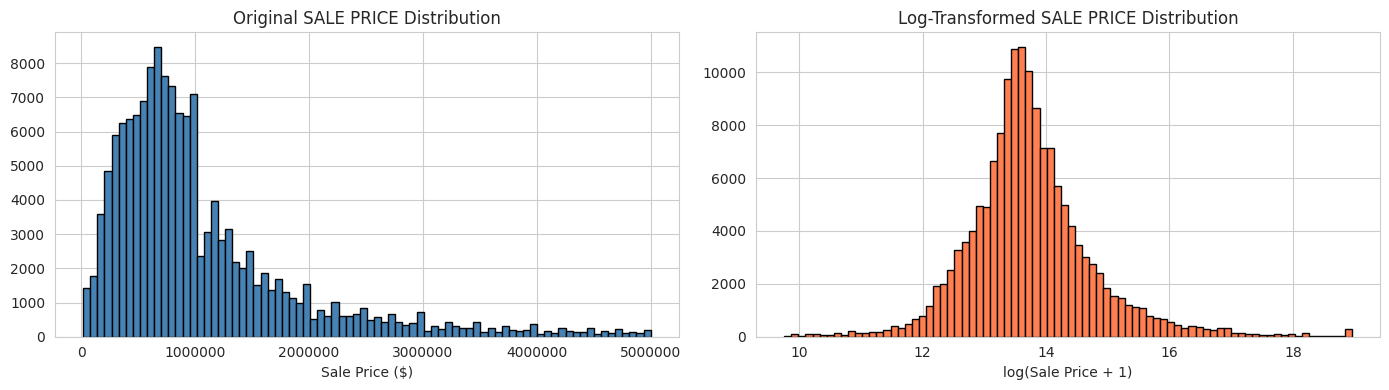

Original SALE PRICE - skewness: 14.37
Log SALE PRICE - skewness: 0.80

(Skewness close to 0 = more normal distribution = better for ML)


In [10]:
# Define target variable (log-transformed for normality)
df['log_sale_price'] = np.log1p(df['SALE PRICE'])

# Visualize transformation effect
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['SALE PRICE'][df['SALE PRICE'] < 5_000_000], bins=80, color='steelblue', edgecolor='black')
axes[0].set_title('Original SALE PRICE Distribution')
axes[0].set_xlabel('Sale Price ($)')
axes[0].ticklabel_format(style='plain', axis='x')

axes[1].hist(df['log_sale_price'], bins=80, color='coral', edgecolor='black')
axes[1].set_title('Log-Transformed SALE PRICE Distribution')
axes[1].set_xlabel('log(Sale Price + 1)')

plt.tight_layout()
plt.savefig(f'{OUTPUTS_PATH}/log_transform_effect.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Original SALE PRICE - skewness: {df['SALE PRICE'].skew():.2f}")
print(f"Log SALE PRICE - skewness: {df['log_sale_price'].skew():.2f}")
print("\n(Skewness close to 0 = more normal distribution = better for ML)")

In [11]:
# Drop columns that are not useful for modeling
columns_to_drop_final = [
    'BOROUGH',           # numeric code, redundant with borough_name dummies
    'ADDRESS',           # too granular, would overfit
    'SALE DATE',         # already extracted month/quarter/dayofweek
    'SALE PRICE',        # this is the target (we use log version)
]

# Keep these for reference but not for modeling
df_modeling = df.drop(columns=columns_to_drop_final).copy()

# Final feature list
target = 'log_sale_price'
features = [col for col in df_modeling.columns if col != target]

print(f"Final feature count: {len(features)}")
print(f"\nFeatures used for modeling:\n")
for i, f in enumerate(features, 1):
    print(f"   {i:2d}. {f}")

Final feature count: 30

Features used for modeling:

    1. NEIGHBORHOOD
    2. BUILDING CLASS CATEGORY
    3. TAX CLASS AT PRESENT
    4. BLOCK
    5. LOT
    6. BUILDING CLASS AT PRESENT
    7. ZIP CODE
    8. RESIDENTIAL UNITS
    9. COMMERCIAL UNITS
   10. TOTAL  UNITS
   11. LAND  SQUARE FEET
   12. GROSS  SQUARE FEET
   13. YEAR BUILT
   14. TAX CLASS AT TIME OF SALE
   15. BUILDING CLASS AT TIME OF SALE
   16. sale_year
   17. sale_month
   18. sale_quarter
   19. sale_dayofweek
   20. building_age
   21. price_per_sqft
   22. borough_avg_price
   23. neighborhood_avg_price
   24. is_recent_construction
   25. has_commercial
   26. borough_bronx
   27. borough_brooklyn
   28. borough_manhattan
   29. borough_queens
   30. borough_staten_island


In [12]:
# Time-based split: train on 2023-2024, test on 2025
# This simulates real-world scenario: predict future prices using past data
print("Performing time-based train/test split...\n")

train_mask = df_modeling['sale_year'].isin([2023, 2024])
test_mask = df_modeling['sale_year'] == 2025

X_train = df_modeling.loc[train_mask, features]
y_train = df_modeling.loc[train_mask, target]

X_test = df_modeling.loc[test_mask, features]
y_test = df_modeling.loc[test_mask, target]

print(f"Train set: {X_train.shape[0]:,} rows ({X_train.shape[0]/len(df_modeling)*100:.1f}%)")
print(f"   Years: {sorted(df_modeling.loc[train_mask, 'sale_year'].unique())}")

print(f"\nTest set: {X_test.shape[0]:,} rows ({X_test.shape[0]/len(df_modeling)*100:.1f}%)")
print(f"   Years: {sorted(df_modeling.loc[test_mask, 'sale_year'].unique())}")

print(f"\nFeatures: {X_train.shape[1]}")

Performing time-based train/test split...

Train set: 99,880 rows (65.1%)
   Years: [np.float64(2023.0), np.float64(2024.0)]

Test set: 53,522 rows (34.9%)
   Years: [np.float64(2025.0)]

Features: 30


In [13]:
# Scale features (important for KNN, SVR, Linear models)
print("Applying StandardScaler to features...\n")

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print(f"Scaled feature stats (should have mean ~0 and std ~1):")
print(X_train_scaled.describe().loc[['mean', 'std']].round(3).iloc[:, :5].to_string())
print("\n... (showing first 5 features only)")

print(f"\nShapes:")
print(f"   X_train_scaled: {X_train_scaled.shape}")
print(f"   X_test_scaled: {X_test_scaled.shape}")

Applying StandardScaler to features...

Scaled feature stats (should have mean ~0 and std ~1):
      NEIGHBORHOOD  BUILDING CLASS CATEGORY  TAX CLASS AT PRESENT  BLOCK  LOT
mean           0.0                      0.0                  -0.0    0.0  0.0
std            1.0                      1.0                   1.0    1.0  1.0

... (showing first 5 features only)

Shapes:
   X_train_scaled: (99880, 30)
   X_test_scaled: (53522, 30)


In [14]:
# Save all processed datasets to Drive for use in Notebook 04
print("Saving processed datasets to Google Drive...\n")

# Save full processed dataset
df_modeling.to_parquet(f'{PROCESSED_DATA_PATH}/processed_data.parquet',
                      compression='snappy', index=False)

# Save train/test splits (both scaled and unscaled)
X_train.to_parquet(f'{PROCESSED_DATA_PATH}/X_train.parquet', compression='snappy', index=False)
X_test.to_parquet(f'{PROCESSED_DATA_PATH}/X_test.parquet', compression='snappy', index=False)
X_train_scaled.to_parquet(f'{PROCESSED_DATA_PATH}/X_train_scaled.parquet', compression='snappy', index=False)
X_test_scaled.to_parquet(f'{PROCESSED_DATA_PATH}/X_test_scaled.parquet', compression='snappy', index=False)

y_train.to_frame().to_parquet(f'{PROCESSED_DATA_PATH}/y_train.parquet', compression='snappy', index=False)
y_test.to_frame().to_parquet(f'{PROCESSED_DATA_PATH}/y_test.parquet', compression='snappy', index=False)

# Save scaler for use in production / Notebook 06 demo
import joblib
joblib.dump(scaler, f'{PROCESSED_DATA_PATH}/scaler.pkl')

print("Files saved successfully:")
files = ['processed_data.parquet', 'X_train.parquet', 'X_test.parquet',
         'X_train_scaled.parquet', 'X_test_scaled.parquet',
         'y_train.parquet', 'y_test.parquet', 'scaler.pkl']

import os
for f in files:
    path = f'{PROCESSED_DATA_PATH}/{f}'
    size_kb = os.path.getsize(path) / 1024
    print(f"   {f}: {size_kb:,.1f} KB")

Saving processed datasets to Google Drive...

Files saved successfully:
   processed_data.parquet: 4,682.6 KB
   X_train.parquet: 2,837.7 KB
   X_test.parquet: 1,550.0 KB
   X_train_scaled.parquet: 2,925.6 KB
   X_test_scaled.parquet: 1,622.0 KB
   y_train.parquet: 266.2 KB
   y_test.parquet: 148.2 KB
   scaler.pkl: 2.1 KB


In [15]:
# Final summary of Notebook 03
print("="*60)
print("NOTEBOOK 03 - PREPROCESSING SUMMARY")
print("="*60)

print(f"\nData transformations applied:")
print(f"   - Removed 86,076 non-commercial transactions (price < $10K)")
print(f"   - Removed 244 extreme price outliers (top/bottom 0.1%)")
print(f"   - Cleaned YEAR BUILT (invalid years marked NaN, imputed by borough median)")
print(f"   - KNN imputation (k=5) for SQUARE FEET columns")
print(f"   - Capped price_per_sqft at 1st-99th percentile")
print(f"   - Log-transformed SALE PRICE (skewness 14.37 -> 0.80)")

print(f"\nFeature engineering:")
print(f"   - 9 new features created (time, age, price ratios, indicators)")
print(f"   - One-hot encoding: borough_name (5 columns)")
print(f"   - Target encoding: 5 high-cardinality categorical variables")
print(f"   - StandardScaler applied to all features")

print(f"\nDataset splits:")
print(f"   - Train: {X_train.shape[0]:,} rows (years 2023-2024)")
print(f"   - Test:  {X_test.shape[0]:,} rows (year 2025)")
print(f"   - Features: {X_train.shape[1]}")

print(f"\nFiles saved to Drive (processed_data/):")
print(f"   - 6 parquet files for train/test splits")
print(f"   - 1 parquet for full processed dataset")
print(f"   - 1 pickle for fitted scaler")

print("\n" + "="*60)
print("Notebook 03 completed successfully.")
print("Next step: Notebook 04 - Model Training (10 ML models)")
print("="*60)

NOTEBOOK 03 - PREPROCESSING SUMMARY

Data transformations applied:
   - Removed 86,076 non-commercial transactions (price < $10K)
   - Removed 244 extreme price outliers (top/bottom 0.1%)
   - Cleaned YEAR BUILT (invalid years marked NaN, imputed by borough median)
   - KNN imputation (k=5) for SQUARE FEET columns
   - Capped price_per_sqft at 1st-99th percentile
   - Log-transformed SALE PRICE (skewness 14.37 -> 0.80)

Feature engineering:
   - 9 new features created (time, age, price ratios, indicators)
   - One-hot encoding: borough_name (5 columns)
   - Target encoding: 5 high-cardinality categorical variables
   - StandardScaler applied to all features

Dataset splits:
   - Train: 99,880 rows (years 2023-2024)
   - Test:  53,522 rows (year 2025)
   - Features: 30

Files saved to Drive (processed_data/):
   - 6 parquet files for train/test splits
   - 1 parquet for full processed dataset
   - 1 pickle for fitted scaler

Notebook 03 completed successfully.
Next step: Notebook 04 - M